In [17]:
import torch
torch_version = str(torch.__version__)
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


In [18]:
import torch
print(torch.__version__)
import torch_geometric
print(torch_geometric.__version__)

2.2.2+cpu
2.6.1


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from torch_geometric.nn import MessagePassing
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_sparse import SparseTensor

class TemporalEncoding(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        effective_size = hidden_size if hidden_size % 2 == 0 else hidden_size + 1

        self.register_buffer(
            "inv_freq",
            1.0 / (10000 ** (torch.arange(0.0, effective_size, 2.0) / effective_size))
        )

    def forward(self, pos):
        sinusoid_inp = pos.float().unsqueeze(-1) * self.inv_freq
        pos_emb = torch.cat([torch.sin(sinusoid_inp), torch.cos(sinusoid_inp)], dim=-1)

        return pos_emb[:, :self.hidden_size]


class CrossDatasetMetaLearner(nn.Module):

    def __init__(
        self,
        hidden_size,
        num_relations,
        num_datasets=1
    ):
        super().__init__()

        self.hidden_size = hidden_size

        self.meta_relation = nn.Embedding(
            num_relations,
            hidden_size
        )

        self.dataset_emb = nn.Embedding(
            num_datasets,
            hidden_size
        )

        self.meta_mlp = nn.Sequential(
            nn.Linear(
                hidden_size,
                hidden_size
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_size,
                hidden_size * hidden_size
                + hidden_size
            )
        )

    def forward(
        self,
        relation_types,
        dataset_id
    ):

        rel_id = relation_types[0]

        rel_emb = self.meta_relation(
            rel_id
        )

        data_emb = self.dataset_emb(
            dataset_id
        )

        meta_input = (
            rel_emb + data_emb
        )

        params = self.meta_mlp(
            meta_input
        )

        weight_size = (
            self.hidden_size
            *
            self.hidden_size
        )

        weight = params[
            :weight_size
        ].view(
            self.hidden_size,
            self.hidden_size
        )

        bias = params[
            weight_size:
        ]

        return {
            'weight': weight,
            'bias': bias
        }
    
    
class HierarchicalAttention(nn.Module):
    """Two-level attention: edge-level and node-level attention"""
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Edge-level attention components
        self.edge_attn_linear = nn.Linear(hidden_size * 3, 1)  # src, dst, relation
        self.edge_attn_activation = nn.LeakyReLU(0.2)

        # Node-level attention components
        self.node_attn_linear = nn.Linear(hidden_size * 2, 1)  # aggregated_msg, self
        self.node_attn_activation = nn.LeakyReLU(0.2)

    def edge_level_attention(self, src_features, dst_features, relation_emb, time_emb):
        """Compute attention weights for each edge"""
        combined = torch.cat([src_features, dst_features, relation_emb + time_emb], dim=-1)
        edge_scores = self.edge_attn_linear(combined)
        edge_scores = self.edge_attn_activation(edge_scores)
        return torch.sigmoid(edge_scores)

    def node_level_attention(self, self_features, aggregated_messages):
        """Compute attention for combining different relation types"""
        combined = torch.cat([self_features, aggregated_messages], dim=-1)
        node_scores = self.node_attn_linear(combined)
        node_scores = self.node_attn_activation(node_scores)
        return torch.sigmoid(node_scores)

class DynamicMetaAttentionConv_Attn(nn.Module):
    """DMAHGT Convolution Layer with Dataset-Aware Meta Learning"""

    def __init__(
        self,
        in_channels,
        out_channels,
        hidden_size,
        num_relations
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_relations = num_relations

        # Relation Embeddings
        self.relation_emb = nn.Embedding(
            num_relations,
            hidden_size
        )

        # Temporal Encoding
        self.temporal_encoding = TemporalEncoding(
            hidden_size
        )

        # Cross-Dataset Meta Learner
        self.meta_learner = CrossDatasetMetaLearner(
            hidden_size,
            num_relations,
            num_datasets=1
        )

        # Hierarchical Attention
        self.hierarchical_attention = (
            HierarchicalAttention(
                hidden_size
            )
        )

        # Feature Transformations
        self.src_transform = nn.Linear(
            in_channels,
            hidden_size
        )

        self.dst_transform = nn.Linear(
            in_channels,
            hidden_size
        )

        self.output_transform = nn.Linear(
            hidden_size,
            out_channels
        )

        self.layer_norm = nn.LayerNorm(
            hidden_size
        )

    def forward(
        self,
        src_x,
        dst_x,
        edge_index,
        edge_type,
        edge_time,
        dataset_id
    ):

        # =====================================
        # Relation Embeddings
        # =====================================
        rel_emb = self.relation_emb(
            edge_type
        )

        # =====================================
        # Temporal Encoding
        # =====================================
        if edge_time is not None:

            time_emb = self.temporal_encoding(
                edge_time.float()
            )

        else:

            time_emb = torch.zeros(
                rel_emb.size(0),
                self.hidden_size,
                device=src_x.device
            )

        # =====================================
        # Dataset-Aware Meta Learning
        # =====================================
        meta_params = self.meta_learner(
            edge_type,
            dataset_id
        )

        # =====================================
        # Node Feature Transformations
        # =====================================
        src_transformed = (
            self.src_transform(src_x)
        )

        dst_transformed = (
            self.dst_transform(dst_x)
        )

        # =====================================
        # Tensor / SparseTensor Support
        # =====================================
        if isinstance(
            edge_index,
            SparseTensor
        ):

            row, col, _ = edge_index.coo()

            src_nodes = src_transformed[
                row
            ]

            dst_nodes = dst_transformed[
                col
            ]

            target_indices = col

        else:

            src_nodes = src_transformed[
                edge_index[0]
            ]

            dst_nodes = dst_transformed[
                edge_index[1]
            ]

            target_indices = edge_index[1]

        # =====================================
        # Edge-Level Attention
        # =====================================
        edge_weights = (
            self.hierarchical_attention
            .edge_level_attention(
                src_nodes,
                dst_nodes,
                rel_emb,
                time_emb
            )
        )

        # =====================================
        # Dynamic Relation Parameters
        # =====================================
        weight = meta_params['weight']
        bias = meta_params['bias']

        transformed_src = (
            src_nodes @ weight
        ) + bias

        # =====================================
        # Attention-Weighted Messages
        # =====================================
        weighted_messages = (
            transformed_src
            * edge_weights
        )

        # =====================================
        # Message Aggregation
        # =====================================
        aggregated = torch.zeros_like(
            dst_transformed
        )

        aggregated.index_add_(
            0,
            target_indices,
            weighted_messages
        )

        # =====================================
        # Node-Level Attention
        # =====================================
        node_weights = (
            self.hierarchical_attention
            .node_level_attention(
                dst_transformed,
                aggregated
            )
        )

        # =====================================
        # Residual Aggregation
        # =====================================
        output = (
            dst_transformed
            +
            aggregated
            * node_weights
        )

        # =====================================
        # LayerNorm
        # =====================================
        output = self.layer_norm(
            output
        )

        # =====================================
        # Output Projection
        # =====================================
        output = self.output_transform(
            output
        )

        return output


class DMA_HGT(nn.Module):

    def __init__(self, hetero_graph, args):
        super().__init__()

        self.hidden_size = args['hidden_size']
        self.num_layers = args['num_layers']
        self.dropout = args['dropout']
        self.device = args['device']

        
        self.dataset_id = torch.tensor(
            0,
            dtype=torch.long,
            device=self.device
        )

        # ==========================
        # Node Embeddings
        # ==========================
                    
        self.node_emb = nn.ModuleDict()
        for node_type in hetero_graph.node_types:
            self.node_emb[node_type] = nn.Embedding(
            hetero_graph[node_type].num_nodes, self.hidden_size
        ).to(self.device)  
            
            

        # ==========================
        # Relation Types
        # ==========================
        self.relation_types = sorted(
            list(
                set(
                    [
                        edge_type[1]
                        for edge_type in hetero_graph.edge_types
                    ]
                )
            )
        )

        self.relation_dict = {
            rel: idx
            for idx, rel in enumerate(
                self.relation_types
            )
        }

        # ==========================
        # DMAHGT Layers
        # ==========================
        self.convs = nn.ModuleList()

        for _ in range(self.num_layers):

            self.convs.append(
                DynamicMetaAttentionConv_Attn(
                    self.hidden_size,
                    self.hidden_size,
                    self.hidden_size,
                    num_relations=len(
                        self.relation_types
                    )
                ).to(self.device)
            )

        # ==========================
        # LayerNorm
        # ==========================
        self.temporal_norm = nn.LayerNorm(
            self.hidden_size
        ).to(self.device)

        # ==========================
        # Explainability
        # ==========================
        self.importance_proj = nn.Linear(
            self.hidden_size,
            1
        ).to(self.device)

    # ==========================================
    # Link Prediction Decoder
    # ==========================================
    def decode(
        self,
        user_emb,
        book_emb,
        edge_index
    ):

        src = user_emb[
        edge_index[0]
        ]

        dst = book_emb[
        edge_index[1]
        ]

        return (
        src * dst
        ).sum(dim=1)

    # ==========================================
    # Forward
    # ==========================================
    def forward(
        self,
        node_features,
        edge_indices,
        edge_timestamps=None
    ):

        x = {}

                   
        for node_type, feat in node_features.items():
            x[node_type] = self.node_emb[node_type](feat.to(self.device).long())
        

        for conv in self.convs:

            x_new = {}

            for (
                message_type,
                edge_index
            ) in edge_indices.items():

                src_type, rel_type, dst_type = (
                    message_type
                )

                if isinstance(
                    edge_index,
                    SparseTensor
                ):

                    nnz = edge_index.nnz()
                    edge_index_tensor = edge_index

                else:

                    nnz = edge_index.size(1)
                    edge_index_tensor = edge_index

                rel_idx = torch.full(
                    (nnz,),
                    self.relation_dict[
                        rel_type
                    ],
                    dtype=torch.long,
                    device=self.device
                )

                if (
                    edge_timestamps is not None
                    and message_type in edge_timestamps
                ):

                    edge_time = (
                        edge_timestamps[
                            message_type
                        ].to(
                            self.device
                        )
                    )

                else:

                    edge_time = torch.zeros(
                        nnz,
                        dtype=torch.float,
                        device=self.device
                    )

                out = conv(
                    src_x=x[src_type],
                    dst_x=x[dst_type],
                    edge_index=edge_index_tensor,
                    edge_type=rel_idx,
                    edge_time=edge_time,
                    dataset_id=self.dataset_id
                )

                if dst_type not in x_new:

                    x_new[dst_type] = out

                else:

                    x_new[dst_type] += out

            for node_type in x:

                if node_type in x_new:

                    x[node_type] = (
                        self.temporal_norm(
                            x[node_type]
                            +
                            x_new[node_type]
                        )
                    )

                x[node_type] = F.dropout(
                    x[node_type],
                    p=self.dropout,
                    training=self.training
                )

        importance = {}

        for node_type in x:

            importance[node_type] = (
                self.importance_proj(
                    x[node_type]
                )
            )

        return x, importance

In [21]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
        
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=max(1, configuration.epochs),eta_min=1e-5)

    return scheduler, optimizer      

## Training and Testing

In [22]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split
import numpy as np

import os

def download_and_extract_amazonbook():

    dataset_folder = os.path.join(
        "amazonbook",
        "amazon-book"
    )

    if not os.path.exists(dataset_folder):

        raise FileNotFoundError(
            f"Dataset folder not found: {dataset_folder}"
        )

    print("AmazonBook dataset found!")

    print(f"Dataset path: {dataset_folder}")

    print("\nDataset files:")

    for file in os.listdir(dataset_folder):
        print(f"  - {file}")

    return dataset_folder

def encode_user_features(num_users, embedding_dim=64):
    
    print("User data info:")
    print("  No user attributes available.")
    print(f"  Creating random features ({embedding_dim} dimensions)")

    user_features = torch.randn(
        num_users,
        embedding_dim
    )

    print(
        f"  User feature dimension: "
        f"{user_features.shape[1]}"
    )

    return user_features


def encode_book_features(num_books, embedding_dim=64):
    """
    Generate initial book features for AmazonBook.

    AmazonBook contains no item attributes,
    so random dense features are used.
    """

    print("Book data info:")
    print("  No book attributes available.")
    print(
        f"  Creating random features "
        f"({embedding_dim} dimensions)"
    )

    book_features = torch.randn(
        num_books,
        embedding_dim
    )

    print(
        f"  Book feature dimension: "
        f"{book_features.shape[1]}"
    )

    return book_features


def load_amazonbook_heterogeneous(
    data_path,
    use_features=True,
    use_temporal=False,
    embedding_dim=64
):
    """
    Load AmazonBook Dataset as Heterogeneous Graph

    Node Types:
        user
        book

    Edge Types:
        (user, interacts, book)
        (book, rev_interacts, user)
    """

    print(f"Loading AmazonBook dataset from: {data_path}")

    print("\nAvailable files in directory:")
    try:
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except Exception:
        print("Could not list directory contents")

    # =====================================================
    # Read Training Interactions
    # =====================================================

    train_file = os.path.join(data_path, "train.txt")
    test_file = os.path.join(data_path, "test.txt")

    user_book_edges = []
    test_edges = []

    max_user = -1
    max_book = -1

    # ==========================================
    # Read train.txt
    # ==========================================
    with open(train_file, "r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) < 2:
                continue

            values = list(map(int, values))
            user = values[0]
            books = values[1:]

            max_user = max(max_user, user)

            for book in books:
                user_book_edges.append([user, book])
                max_book = max(max_book, book)

    # ==========================================
    # Scan test.txt for maximum ids
    # ==========================================
    if os.path.exists(test_file):
        print("✓ Found test.txt")

        with open(test_file, "r") as f:
            for line in f:
                values = line.strip().split()

                if len(values) < 2:
                    continue

                values = list(map(int, values))
                user = values[0]
                books = values[1:]

                max_user = max(max_user, user)

                for book in books:
                    test_edges.append([user, book])
                    max_book = max(max_book, book)
                  
    else:
        print("⚠ test.txt not found")

    num_users = max_user + 1
    num_books = max_book + 1

    print(
        f"\nStatistics - Users: {num_users}, Books: {num_books}"
    )

    # =====================================================
    # Create Heterogeneous Graph
    # =====================================================

    data = HeteroData()

    data["user"].num_nodes = num_users
    data["book"].num_nodes = num_books

    # =====================================================
    # Node Features
    # =====================================================

    user_feat_dim = 0
    book_feat_dim = 0

    if use_features:
        
        torch.manual_seed(42)

        user_features = torch.randn(
            num_users,
            embedding_dim
        )

        book_features = torch.randn(
            num_books,
            embedding_dim
        )

        data["user"].x = user_features
        data["book"].x = book_features

        user_feat_dim = embedding_dim
        book_feat_dim = embedding_dim

        print("\nFeature dimensions:")
        print(
            f"  User features: {user_feat_dim} dims"
        )
        print(
            f"  Book features: {book_feat_dim} dims"
        )

    # =====================================================
    # Edge Construction
    # =====================================================

    edge_index = torch.tensor(
        user_book_edges,
        dtype=torch.long
    ).t().contiguous()

    num_edges = edge_index.size(1)

    print(
        f"\nUser-interacts-book relations: {num_edges}"
    )

    # Forward relation

    data[
        "user",
        "interacts",
        "book"
    ].edge_index = edge_index

    # Reverse relation

    data[
        "book",
        "rev_interacts",
        "user"
    ].edge_index = edge_index.flip(0)

    # Save original edges

    data[
        "user",
        "interacts",
        "book"
    ].original_edge_index = edge_index.clone()
    
    if len(test_edges) > 0:

        data.test_pos_edge_index = (
            torch.tensor(
                test_edges,
                dtype=torch.long
            )
            .t()
            .contiguous()
        )

        print(
            f"Official Test Edges: "
            f"{data.test_pos_edge_index.size(1)}"
        )

    # =====================================================
    # Statistics
    # =====================================================

    print("\nFINAL STATISTICS:")

    print(
        f"  Users: {data['user'].num_nodes}"
    )

    print(
        f"  Books: {data['book'].num_nodes}"
    )

    print(
        f"  User→Book edges: {num_edges}"
    )

    print(
        f"  User feature dimension: {user_feat_dim}"
    )

    print(
        f"  Book feature dimension: {book_feat_dim}"
    )

    return (
        data,
        user_feat_dim,
        book_feat_dim
    )



def train_link_prediction_model(data, model, configuration):
    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=configuration.epochs,
        eta_min=1e-5
    )

    losses = []
    val_aucs = []
    best_val_auc = 0.0
    best_model_state = None
    num_epochs = configuration.epochs

    for epoch in trange(num_epochs, desc="DMAHGT Training"):
        model.train()
        optimizer.zero_grad()

        #node_features = {node_type: data[node_type].x for node_type in data.node_types}
        #node_features = {node_type: torch.arange(data[node_type].num_nodes,device=device)for node_type in data.node_types}
        node_features = {node_type: torch.arange(data[node_type].num_nodes, device=model.device) for node_type in data.node_types}
        edge_indices = {edge_type: data[edge_type].edge_index for edge_type in data.edge_types}
        edge_timestamps = {}

        for edge_type in data.edge_types:
            if "timestamp" in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(node_features, edge_indices, edge_timestamps)
        user_emb = z["user"]
        book_emb = z["book"]

        pos_edge_index = data.train_pos_edge_index
        '''num_pos = pos_edge_index.size(1)

        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=(data["user"].num_nodes, data["book"].num_nodes),
            num_neg_samples=num_pos
        )'''
        
        
        num_pos = pos_edge_index.size(1)

        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=(data["user"].num_nodes, data["book"].num_nodes),
            num_neg_samples=num_pos * 4,
            method='sparse'
        )

        #pos_pred = model.decode(user_emb, book_emb, pos_edge_index)
        #neg_pred = model.decode(user_emb, book_emb, neg_edge_index)

        #pos_loss = -torch.log(torch.sigmoid(pos_pred) + 1e-15).mean()
        #neg_loss = -torch.log(1 - torch.sigmoid(neg_pred) + 1e-15).mean()
        
        #pos_loss = F.binary_cross_entropy_with_logits(pos_pred, torch.ones_like(pos_pred))
        #neg_loss = F.binary_cross_entropy_with_logits(neg_pred, torch.zeros_like(neg_pred))
        #loss = pos_loss + neg_loss
        pos_pred = model.decode(user_emb, book_emb, pos_edge_index)          # shape [num_pos]
        neg_pred = model.decode(user_emb, book_emb, neg_edge_index)          # shape [num_pos * 4]
        neg_pred = neg_pred.view(4, -1).mean(dim=0)                          # avg 4 negs per positive -> [num_pos]

        loss = -F.logsigmoid(pos_pred - neg_pred).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        losses.append(loss.item())

        if epoch % 5 == 0:
            model.eval()
            with torch.no_grad():
                z, importance = model(node_features, edge_indices, edge_timestamps)
                user_emb = z["user"]
                book_emb = z["book"]

                val_pred = model.decode(user_emb, book_emb, data.val_edge_index)
                val_pred = torch.sigmoid(val_pred)

                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_pred.cpu().numpy()
                )
                val_aucs.append(val_auc)

                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        #node_features = {node_type: data[node_type].x for node_type in data.node_types}
        node_features = {node_type: torch.arange(data[node_type].num_nodes, device=model.device) for node_type in data.node_types}
        edge_indices = {edge_type: data[edge_type].edge_index for edge_type in data.edge_types}
        edge_timestamps = {}

        for edge_type in data.edge_types:
            if "timestamp" in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(node_features, edge_indices, edge_timestamps)
        user_emb = z["user"]
        book_emb = z["book"]

        test_pred = model.decode(user_emb, book_emb, data.test_edge_index)
        test_pred = torch.sigmoid(test_pred)

        test_auc = roc_auc_score(data.test_edge_label.cpu().numpy(), test_pred.cpu().numpy())
        test_ap = average_precision_score(data.test_edge_label.cpu().numpy(), test_pred.cpu().numpy())

    test_metrics = {"auc": test_auc, "ap": test_ap}
    return val_aucs, losses, model, test_metrics


def evaluate_recommendation_clean(model, data, k_list=[5, 10, 20]):
    """
    Recommendation Evaluation

    Computes:
        HR@K
        NDCG@K
        MRR
    """
    model.eval()

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    with torch.no_grad():
        # =====================================
        # Generate embeddings
        # =====================================
        #node_features = {node_type: data[node_type].x for node_type in data.node_types}
        node_features = {node_type: torch.arange(data[node_type].num_nodes, device=model.device) for node_type in data.node_types}
        edge_indices = {edge_type: data[edge_type].edge_index for edge_type in data.edge_types}
        edge_timestamps = {}

        for edge_type in data.edge_types:
            if "timestamp" in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, _ = model(node_features, edge_indices, edge_timestamps)
        user_emb = z["user"]
        book_emb = z["book"]

        # =====================================
        # Positive Test Edges
        # =====================================
        pos_edges = data.test_edge_index[:, data.test_edge_label == 1]

        if pos_edges.size(1) == 0:
            print("Warning: No positive test edges.")
            results = {}
            for k in k_list:
                results[f"HR@{k}"] = 0
                results[f"NDCG@{k}"] = 0
            results["MRR"] = 0
            return results

        # =====================================
        # Evaluate subset
        # =====================================
        max_eval_edges = 5000

        if pos_edges.size(1) > max_eval_edges:
            eval_idx = np.random.choice(pos_edges.size(1), max_eval_edges, replace=False)
            pos_edges = pos_edges[:, eval_idx]

        # =====================================
        # User History
        # =====================================
        user_positive_items = {}
        positive_edges = data.train_edge_index[:, data.train_edge_label == 1]

        for i in range(positive_edges.size(1)):
            user = positive_edges[0, i].item()
            book = positive_edges[1, i].item()

            if user not in user_positive_items:
                user_positive_items[user] = set()
            user_positive_items[user].add(book)

        # =====================================
        # Candidate Books
        # =====================================
        all_books = set(range(data["book"].num_nodes))

        # =====================================
        # Evaluation Loop
        # =====================================
        for edge in pos_edges.t():
            user = edge[0].item()
            pos_book = edge[1].item()

            user_seen = user_positive_items.get(user, set())
            candidate_books = list(all_books - user_seen)

            if len(candidate_books) < 49:
                continue

            neg_books = np.random.choice(candidate_books, 49, replace=False)
            candidates = list(neg_books) + [pos_book]

            users = torch.full((len(candidates),), user, dtype=torch.long, device=user_emb.device)
            books = torch.tensor(candidates, dtype=torch.long, device=user_emb.device)
            edge_index = torch.stack([users, books])

            scores = model.decode(user_emb, book_emb, edge_index)
            scores = scores.cpu().numpy()

            ranking = np.argsort(scores)[::-1]
            ranked_books = [candidates[i] for i in ranking]

            for k in k_list:
                if pos_book in ranked_books[:k]:
                    HR[k].append(1)
                    rank = ranked_books.index(pos_book) + 1
                    NDCG[k].append(1.0 / np.log2(rank + 1))
                else:
                    HR[k].append(0)
                    NDCG[k].append(0)

            rank = ranked_books.index(pos_book) + 1
            MRR.append(1.0 / rank)

    # =====================================
    # Final Metrics
    # =====================================
    results = {}
    for k in k_list:
        results[f"HR@{k}"] = np.mean(HR[k]) if len(HR[k]) > 0 else 0
        results[f"NDCG@{k}"] = np.mean(NDCG[k]) if len(NDCG[k]) > 0 else 0

    results["MRR"] = np.mean(MRR) if len(MRR) > 0 else 0
    return results


class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)

In [23]:
from torch_geometric.utils import negative_sampling

def prepare_link_prediction_data(data, val_ratio=0.1):
    train_edge_index = data['user', 'interacts', 'book'].edge_index
    test_pos_edge_index = data.test_pos_edge_index
    num_edges = train_edge_index.size(1)

    # If temporal data is available, split chronologically to prevent future leakage
    if 'timestamp' in data['user', 'interacts', 'book']:
        timestamps = data['user', 'interacts', 'book'].timestamp
        perm = torch.argsort(timestamps)
    else:
        perm = torch.randperm(num_edges)

    num_val = int(num_edges * val_ratio)
    train_idx = perm[:-num_val]
    val_idx = perm[-num_val:]

    train_pos_edge_index = train_edge_index[:, train_idx]
    val_pos_edge_index = train_edge_index[:, val_idx]

    # Training negatives
    train_neg_edge_index = negative_sampling(
        edge_index=train_edge_index,
        num_nodes=(data['user'].num_nodes, data['book'].num_nodes),
        num_neg_samples=train_pos_edge_index.size(1)
    )

    # Validation negatives
    val_neg_edge_index = negative_sampling(
        edge_index=train_edge_index,
        num_nodes=(data['user'].num_nodes, data['book'].num_nodes),
        num_neg_samples=val_pos_edge_index.size(1)
    )

    # Test negatives
    test_neg_edge_index = negative_sampling(
        edge_index=train_edge_index,
        num_nodes=(data['user'].num_nodes, data['book'].num_nodes),
        num_neg_samples=test_pos_edge_index.size(1)
    )

    # Assign Train
    data.train_pos_edge_index = train_pos_edge_index
    data.train_edge_index = torch.cat([train_pos_edge_index, train_neg_edge_index], dim=1)
    data.train_edge_label = torch.cat([
        torch.ones(train_pos_edge_index.size(1), device=train_edge_index.device),
        torch.zeros(train_neg_edge_index.size(1), device=train_edge_index.device)
    ])

    # Assign Validation
    data.val_edge_index = torch.cat([val_pos_edge_index, val_neg_edge_index], dim=1)
    data.val_edge_label = torch.cat([
        torch.ones(val_pos_edge_index.size(1), device=train_edge_index.device),
        torch.zeros(val_neg_edge_index.size(1), device=train_edge_index.device)
    ])

    # Assign Test
    data.test_edge_index = torch.cat([test_pos_edge_index, test_neg_edge_index], dim=1)
    data.test_edge_label = torch.cat([
        torch.ones(test_pos_edge_index.size(1), device=train_edge_index.device),
        torch.zeros(test_neg_edge_index.size(1), device=train_edge_index.device)
    ])

    # Extract matching timestamps for positive and negative samples if using temporal logic
    if 'timestamp' in data['user', 'interacts', 'book']:
        train_pos_ts = timestamps[train_idx]
        val_pos_ts = timestamps[val_idx]
        test_pos_ts = data.test_pos_timestamp if hasattr(data, 'test_pos_timestamp') else torch.zeros(test_pos_edge_index.size(1), device=train_edge_index.device)

        # Mirror positive interaction times onto negative samples as a baseline for the decoder
        data.train_edge_timestamp = torch.cat([train_pos_ts, train_pos_ts])
        data.val_edge_timestamp = torch.cat([val_pos_ts, val_pos_ts])
        data.test_edge_timestamp = torch.cat([test_pos_ts, test_pos_ts])

    return data

Using device: cpu

STEP 1: Loading AmazonBook Dataset
AmazonBook dataset found!
Dataset path: amazonbook\amazon-book

Dataset files:
  - item_list.txt
  - README.md
  - test.txt
  - train.txt
  - user_list.txt
Loading AmazonBook dataset from: amazonbook\amazon-book

Available files in directory:
  - item_list.txt
  - README.md
  - test.txt
  - train.txt
  - user_list.txt
✓ Found test.txt

Statistics - Users: 52643, Books: 91599

Feature dimensions:
  User features: 64 dims
  Book features: 64 dims

User-interacts-book relations: 2380730
Official Test Edges: 603378

FINAL STATISTICS:
  Users: 52643
  Books: 91599
  User→Book edges: 2380730
  User feature dimension: 64
  Book feature dimension: 64

STEP 2: Preparing Data for Link Prediction

STEP 3: Building DMAHGT Model

STEP 4: Training DMAHGT


DMAHGT Training: 100%|█████████████████████████████████████████████████████████████| 300/300 [1:53:10<00:00, 22.64s/it]



STEP 5: Recommendation Evaluation

FINAL RESULTS
AUC: 0.7359
AP: 0.6707
HR@5: 0.4286
HR@10: 0.5970
HR@20: 0.7828
NDCG@5: 0.2968
NDCG@10: 0.3513
NDCG@20: 0.3985
MRR: 0.2959
Training Time: 6795.88 seconds


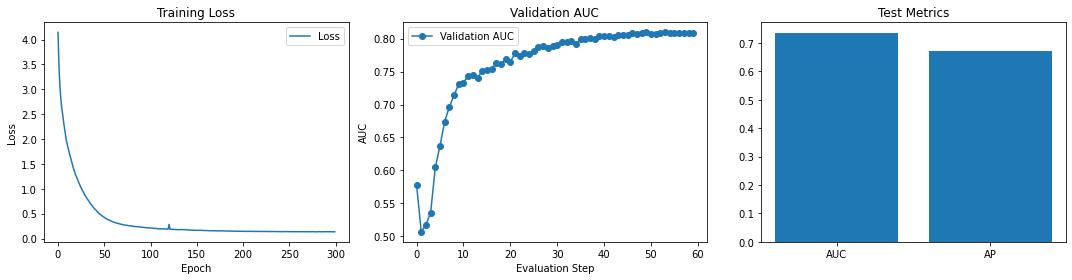

In [24]:
import torch
import time
import matplotlib.pyplot as plt

def main_link_prediction():
    configurations = [{
        'model_type': 'DMAHGT',
        'dataset': 'AmazonBook',
        'num_layers': 2,
        'heads': 1,
        'hidden_dim': 64,
        'embedding_dim': 64,
        'dropout': 0.2,
        'epochs': 300,
        'optimizer': 'adam',
        'weight_decay': 5e-6,
        'learning_rate': 5e-4,
        'num_relation_types': 1,
        'use_temporal': False,
        'use_features': True
    }]

    for config_dict in configurations:
        config = Config(config_dict)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")

        print("\n" + "=" * 60)
        print("STEP 1: Loading AmazonBook Dataset")
        print("=" * 60)
        data_path = download_and_extract_amazonbook()
        heterogeneous_data, user_feat_dim, book_feat_dim = load_amazonbook_heterogeneous(
            data_path, use_features=True, embedding_dim=64
        )

        config.user_feat_dim = user_feat_dim
        config.book_feat_dim = book_feat_dim
        heterogeneous_data = heterogeneous_data.to(device)

        print("\n" + "=" * 60)
        print("STEP 2: Preparing Data for Link Prediction")
        print("=" * 60)
        heterogeneous_data = prepare_link_prediction_data(heterogeneous_data)

        print("\n" + "=" * 60)
        print("STEP 3: Building DMAHGT Model")
        print("=" * 60)
        model_args = {
            'device': device,
            'hidden_size': config.hidden_dim,
            'num_layers': config.num_layers,
            'dropout': config.dropout
        }
        model = DMA_HGT(heterogeneous_data, model_args).to(device)

        print("\n" + "=" * 60)
        print("STEP 4: Training DMAHGT")
        print("=" * 60)
        start_time = time.time()
        val_aucs, losses, best_model, test_metrics = train_link_prediction_model(
            heterogeneous_data, model, config
        )
        elapsed_time = time.time() - start_time

        print("\n" + "=" * 60)
        print("STEP 5: Recommendation Evaluation")
        print("=" * 60)
        rec_metrics = evaluate_recommendation_clean(best_model, heterogeneous_data)

        print("\n" + "=" * 60)
        print("FINAL RESULTS")
        print("=" * 60)
        print(f"AUC: {test_metrics['auc']:.4f}")
        print(f"AP: {test_metrics['ap']:.4f}")
        print(f"HR@5: {rec_metrics['HR@5']:.4f}")
        print(f"HR@10: {rec_metrics['HR@10']:.4f}")
        print(f"HR@20: {rec_metrics['HR@20']:.4f}")
        print(f"NDCG@5: {rec_metrics['NDCG@5']:.4f}")
        print(f"NDCG@10: {rec_metrics['NDCG@10']:.4f}")
        print(f"NDCG@20: {rec_metrics['NDCG@20']:.4f}")
        print(f"MRR: {rec_metrics['MRR']:.4f}")
        print(f"Training Time: {elapsed_time:.2f} seconds")

        # ==================================
        # Visualization
        # ==================================
        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.plot(losses, label="Loss")
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(val_aucs, marker='o', label='Validation AUC')
        plt.title("Validation AUC")
        plt.xlabel("Evaluation Step")
        plt.ylabel("AUC")
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.bar(['AUC', 'AP'], [test_metrics['auc'], test_metrics['ap']])
        plt.title("Test Metrics")

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main_link_prediction()